# Evaluation of the effect of Markov chain length
***

Jan T. Schleicher, 2025

Here, we evaluate the hierarchical clustering solutions of exploratory trajectory inference for different simulated chain lengths.
Additionally, we use repeated analyses to assess the uncertainty of the inferred lineages through comparison of the results of repeated runs.

In [1]:
import glob
import json
import logging
import sys

import cy2path as c2p
import matplotlib as mpl
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from dtaidistance import dtw_ndim
from matplotlib import pyplot as plt

In [2]:
mpl.rcParams["figure.dpi"] = 300
logging.disable(sys.maxsize)

In [3]:
# Import AnnData object
adata = sc.read_h5ad("../data/tex_data_chronic_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [ ]:
# Load clustering results
SIMULATIONS_PATH = "../output/markov_chains/20250512_1405"
LINEAGE_PATH = "../output/lineage_clustering/20250519_0845/"
silhouette_scores_dict = {}
clusterings_dict = {}
markov_chains_dict = {}

for folder in glob.glob(f"{LINEAGE_PATH}/*_steps"):
    num_steps = int(folder.split("/")[-1].split("_")[0])
    silhouette_scores_dict[num_steps] = {}
    clusterings_dict[num_steps] = {}

    for file in glob.glob(f"{folder}/silhouette_scores_*.json"):
        run_number = int(file.split("_")[-1].split(".")[0])
        markov_chains_dict[run_number] = np.load(
            f"{SIMULATIONS_PATH}/simulations_{run_number}.npy"
        )
        silhouette_scores_dict[num_steps][run_number] = json.load(open(file))
        clusterings_dict[num_steps][run_number] = {}

        for clust_file in glob.glob(f"{folder}/*_{run_number}.npy"):
            num_lineages = int(clust_file.split("_")[-2])
            clusterings_dict[num_steps][run_number][num_lineages] = np.load(clust_file)

In [ ]:
silhouette_scores_df = (
    pd.concat(
        {key: pd.DataFrame(val) for key, val in silhouette_scores_dict.items()},
        names=["num_steps", "num_lineages"],
    )
    .reset_index()
    .melt(
        id_vars=["num_lineages", "num_steps"],
        var_name="run",
        value_name="silhouette_score",
    )
)
silhouette_scores_df

,num_lineages,num_steps,run,silhouette_score
0,2,50,3,0.153441
1,3,50,3,0.133099
2,4,50,3,0.098692
3,2,100,3,0.132151
4,3,100,3,0.071542
...,...,...,...,...
175,3,200,0,0.104894
176,4,200,0,0.027606
177,2,500,0,0.057769
178,3,500,0,0.046725


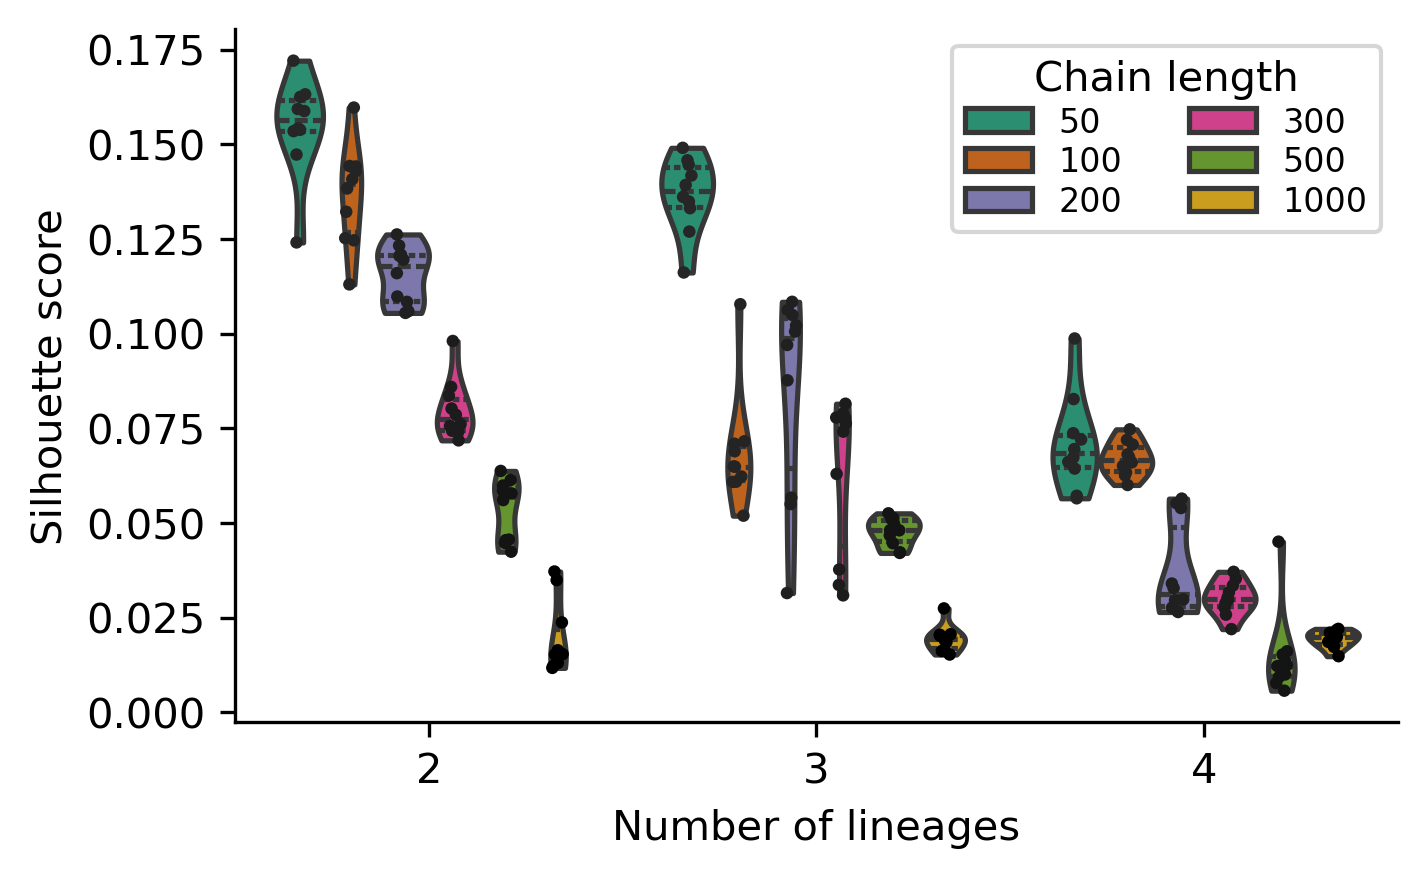

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.violinplot(
    silhouette_scores_df,
    x="num_lineages",
    y="silhouette_score",
    hue="num_steps",
    inner="quartiles",
    cut=0,
    palette="Dark2",
    ax=ax,
)
sns.stripplot(
    silhouette_scores_df,
    x="num_lineages",
    y="silhouette_score",
    hue="num_steps",
    dodge=True,
    legend=False,
    color="k",
    ax=ax,
    s=3,
)
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
ax.legend(
    handles,
    labels,
    loc="upper right",
    ncol=2,
    fontsize=8,
    labelspacing=0.2,
    title="Chain length",
)
ax.set_xlabel("Number of lineages")
ax.set_ylabel("Silhouette score")
sns.despine(fig)

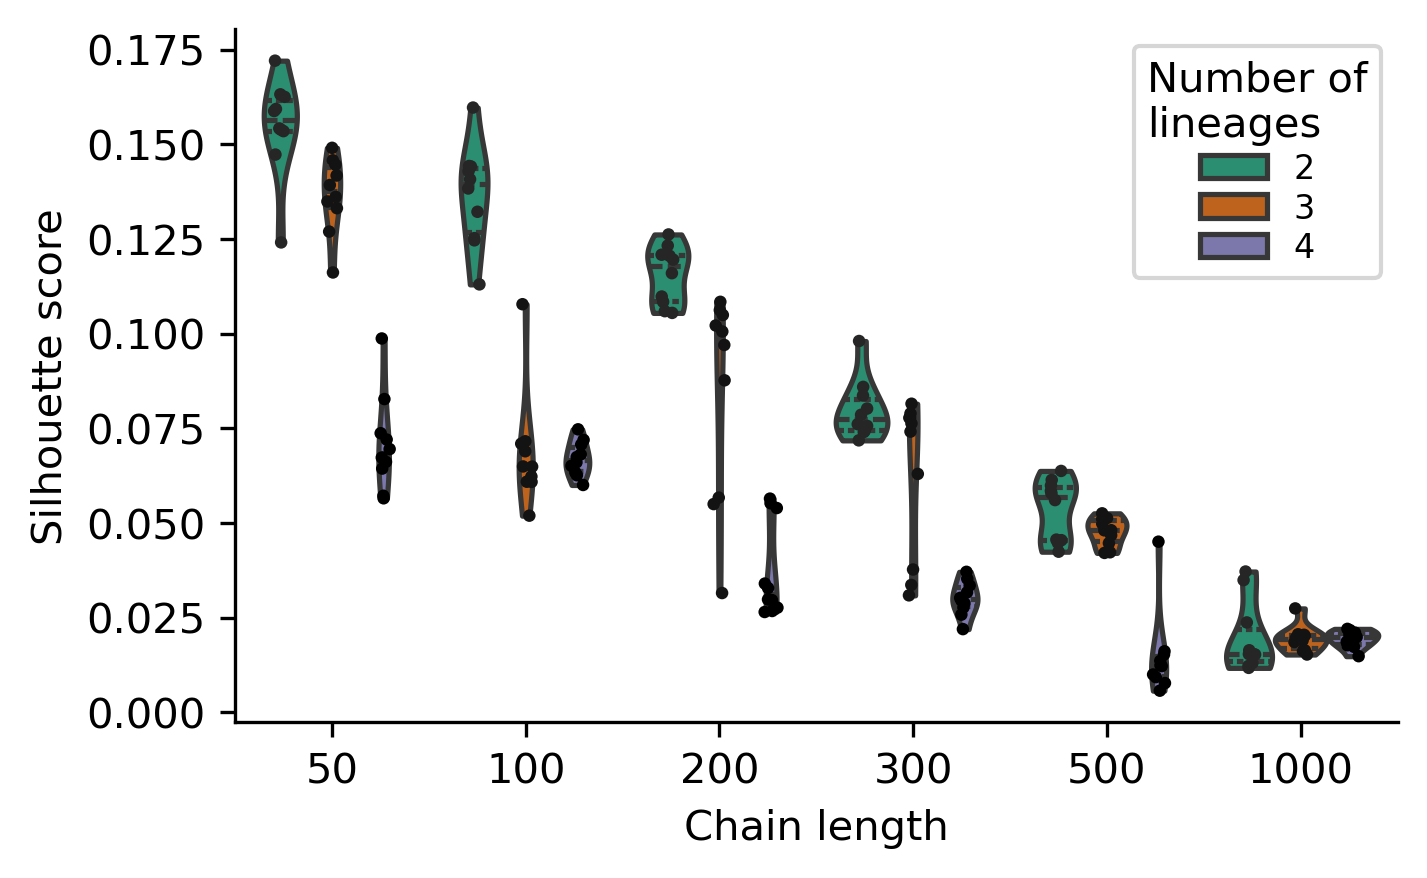

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.violinplot(
    silhouette_scores_df,
    x="num_steps",
    y="silhouette_score",
    hue="num_lineages",
    inner="quartiles",
    cut=0,
    palette="Dark2",
    ax=ax,
)
sns.stripplot(
    silhouette_scores_df,
    x="num_steps",
    y="silhouette_score",
    hue="num_lineages",
    dodge=True,
    legend=False,
    color="k",
    ax=ax,
    s=3,
)
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
ax.legend(
    handles,
    labels,
    loc="upper right",
    ncol=1,
    fontsize=8,
    labelspacing=0.2,
    title="Number of\nlineages",
)
ax.set_xlabel("Chain length")
ax.set_ylabel("Silhouette score")
sns.despine(fig)

In [8]:
adata_ = adata.copy()

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

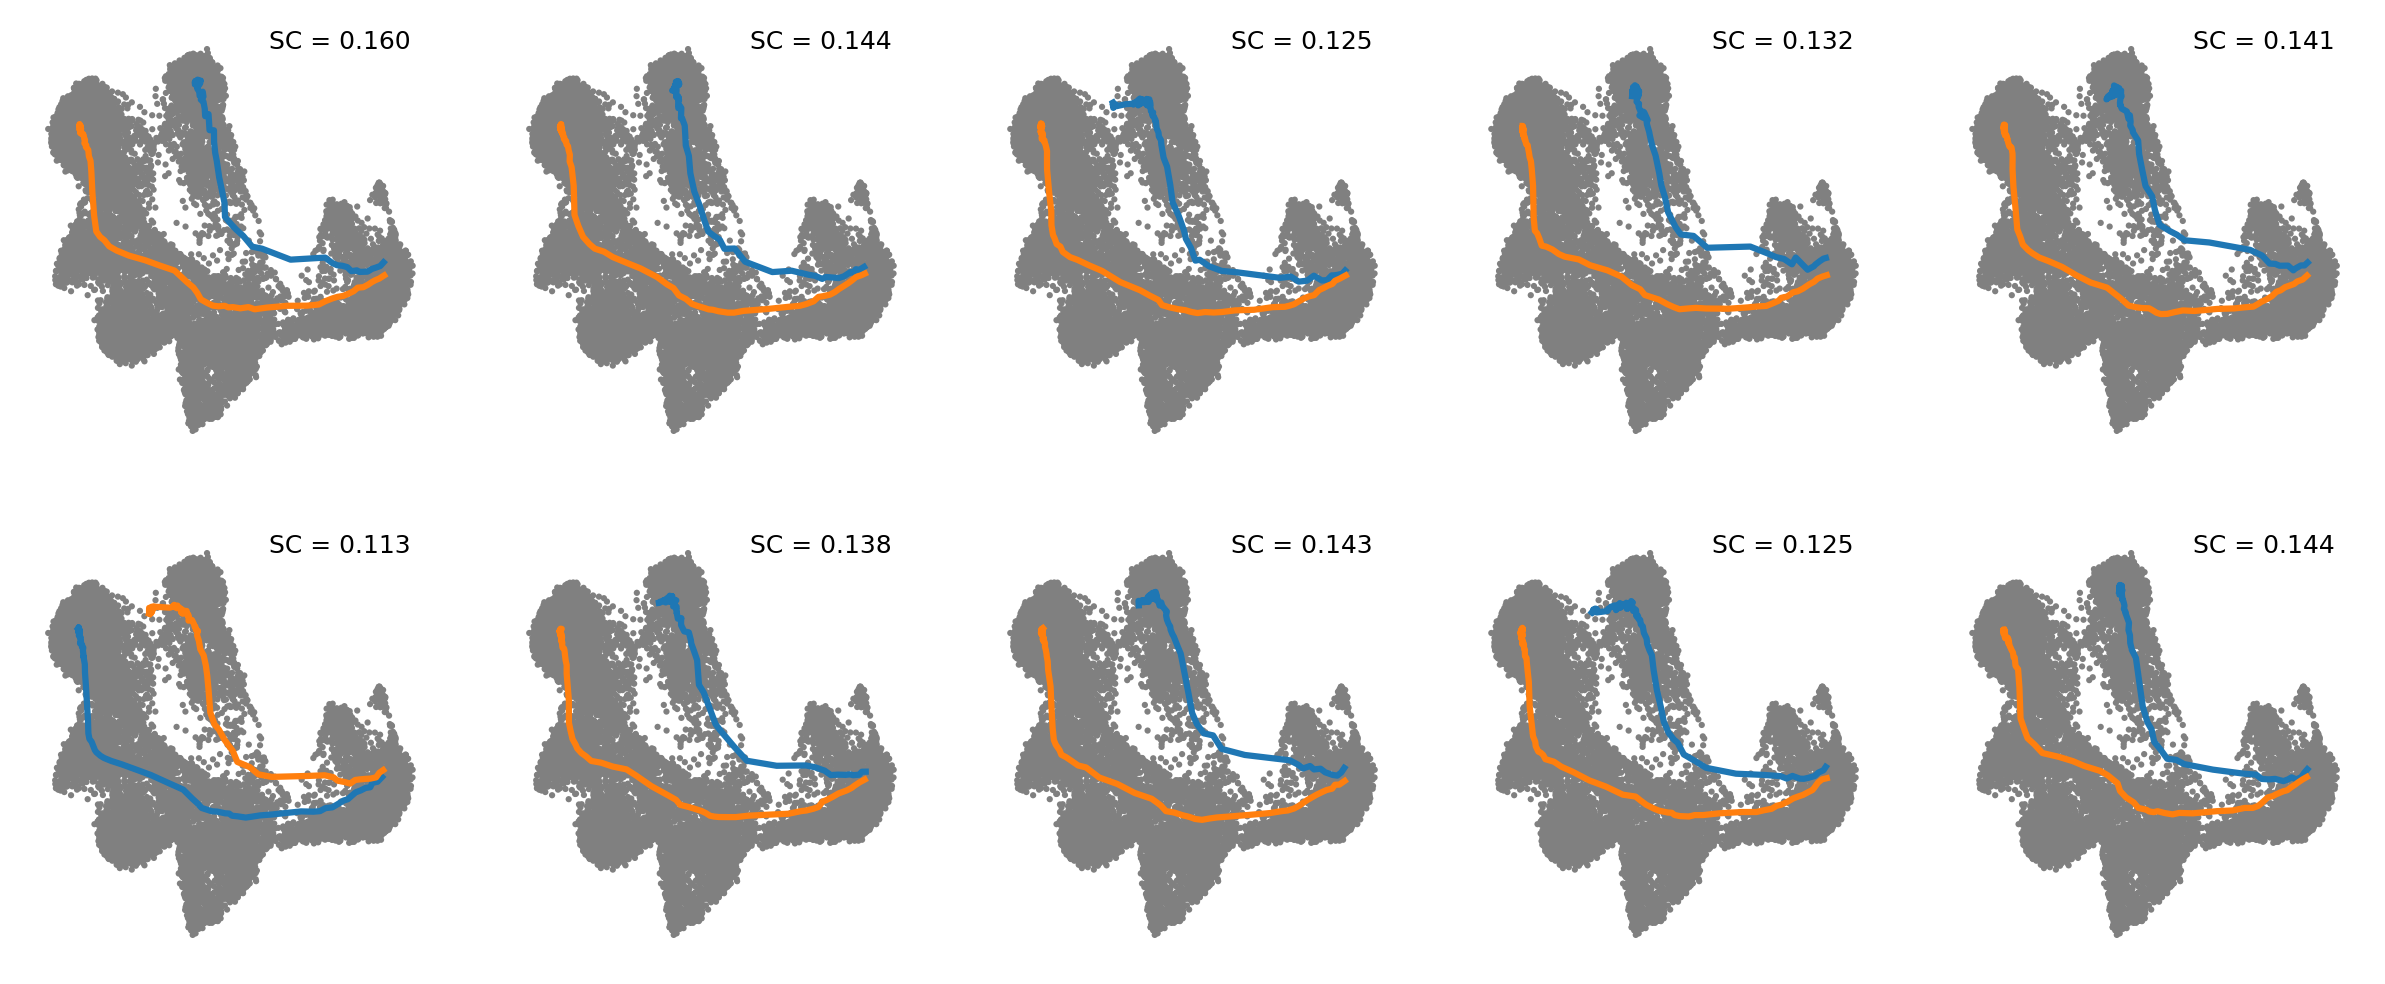

In [ ]:
# Plot for 2 lineages, 100 steps
n_lineages = 2
num_steps = 100
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for run_number, markov_chains in markov_chains_dict.items():
    adata_.uns["markov_chain_sampling"] = {}
    adata_.uns["markov_chain_sampling"]["state_indices"] = markov_chains[:, :num_steps]
    adata_.uns["cytopath"] = {}
    adata_.uns["cytopath"]["lineage_inference_clusters"] = clusterings_dict[num_steps][
        run_number
    ][n_lineages]
    c2p.plot_cytopath_lineages(adata_, basis="umap", ax=axs.flat[run_number])
    axs.flat[run_number].text(
        0.95,
        1.0,
        f"SC = {silhouette_scores_dict[num_steps][run_number][str(n_lineages)]:.3f}",
        ha="right",
        va="top",
        transform=axs.flat[run_number].transAxes,
        size=6,
    )

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

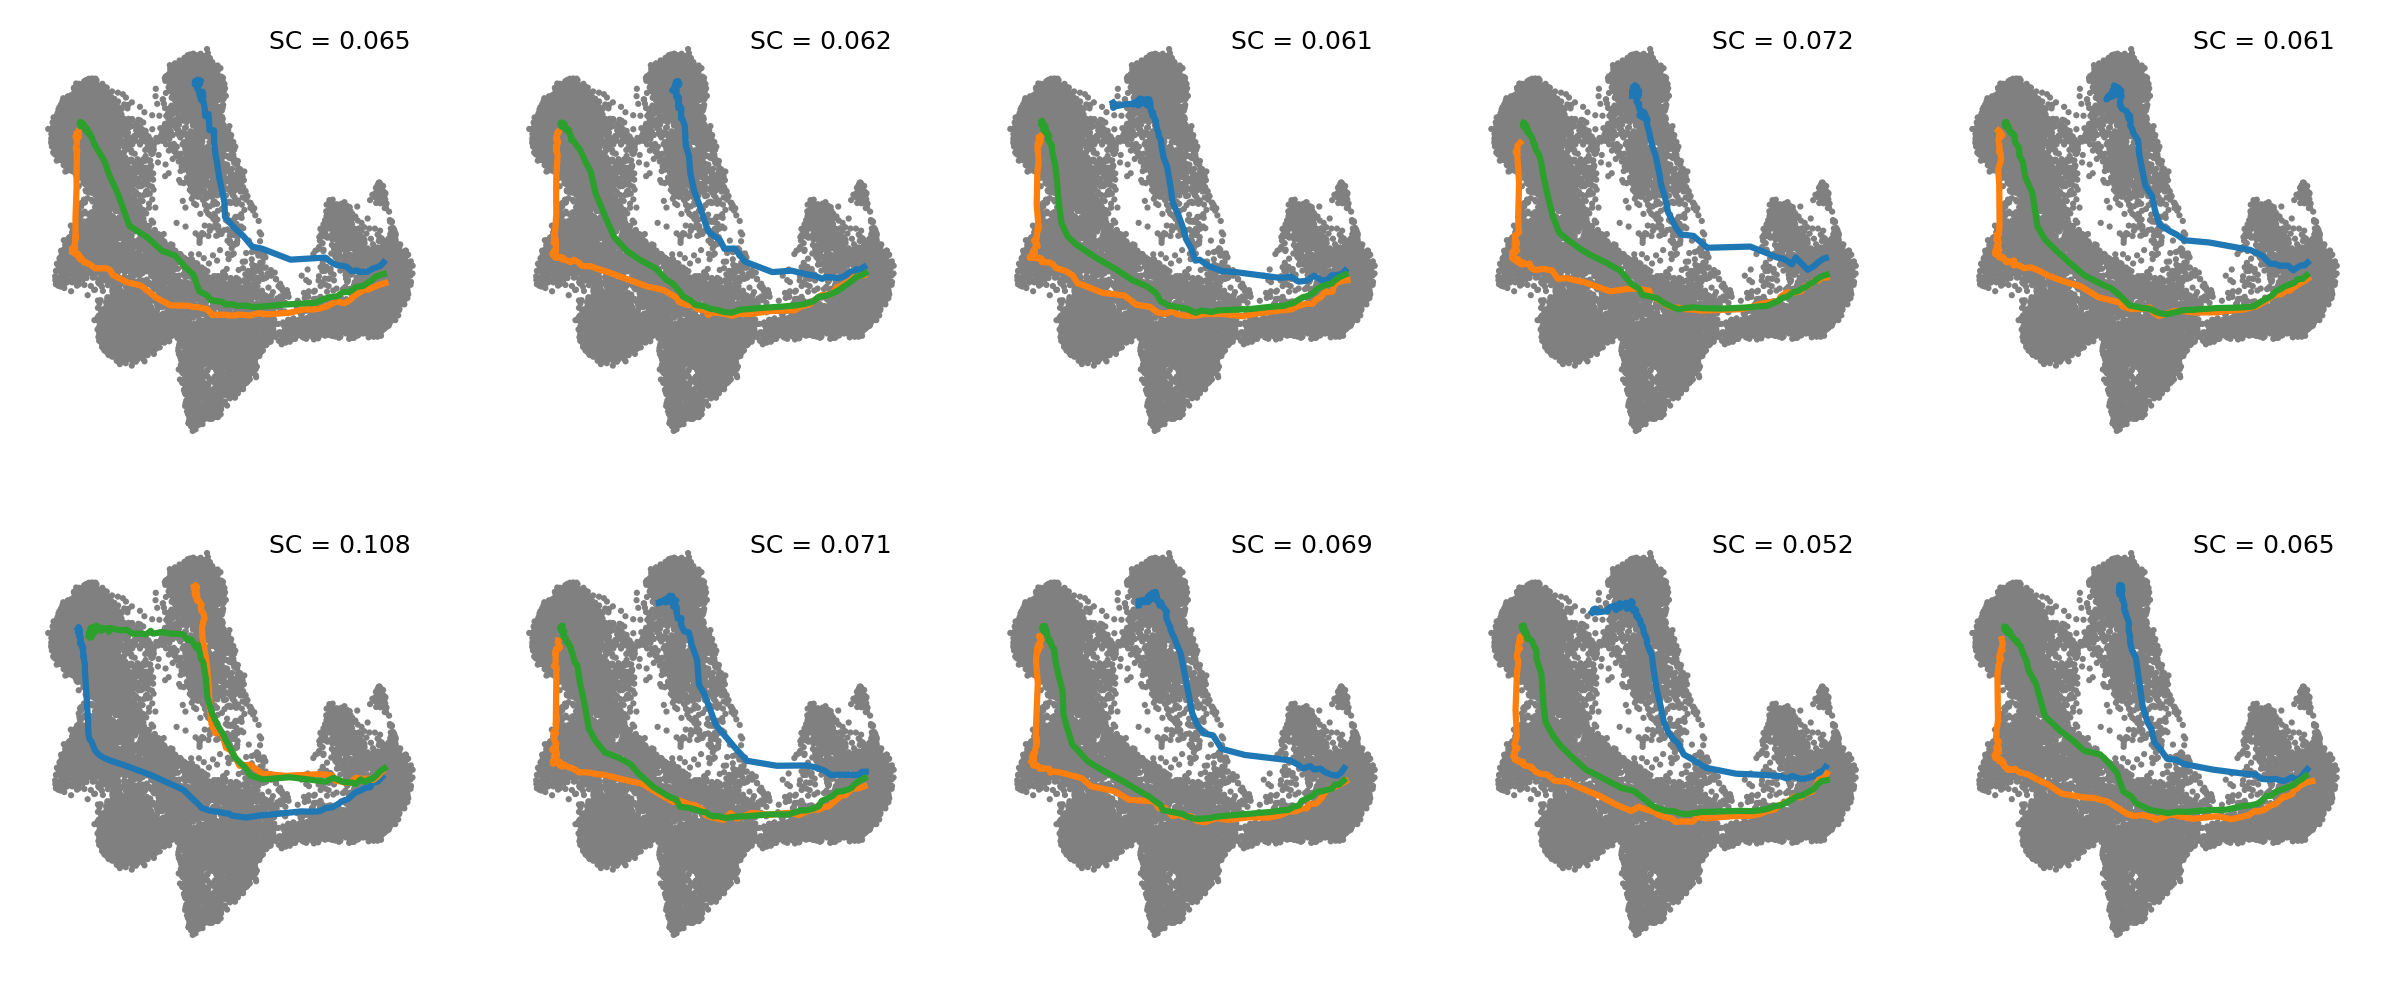

In [10]:
# Plot for 3 lineages, 100 steps
n_lineages = 3
num_steps = 100
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for run_number, markov_chains in markov_chains_dict.items():
    adata_.uns["markov_chain_sampling"] = {}
    adata_.uns["markov_chain_sampling"]["state_indices"] = markov_chains[:, :num_steps]
    adata_.uns["cytopath"] = {}
    adata_.uns["cytopath"]["lineage_inference_clusters"] = clusterings_dict[num_steps][
        run_number
    ][n_lineages]
    c2p.plot_cytopath_lineages(adata_, basis="umap", ax=axs.flat[run_number])
    axs.flat[run_number].text(
        0.95,
        1.0,
        f"SC = {silhouette_scores_dict[num_steps][run_number][str(n_lineages)]:.3f}",
        ha="right",
        va="top",
        transform=axs.flat[run_number].transAxes,
        size=6,
    )

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

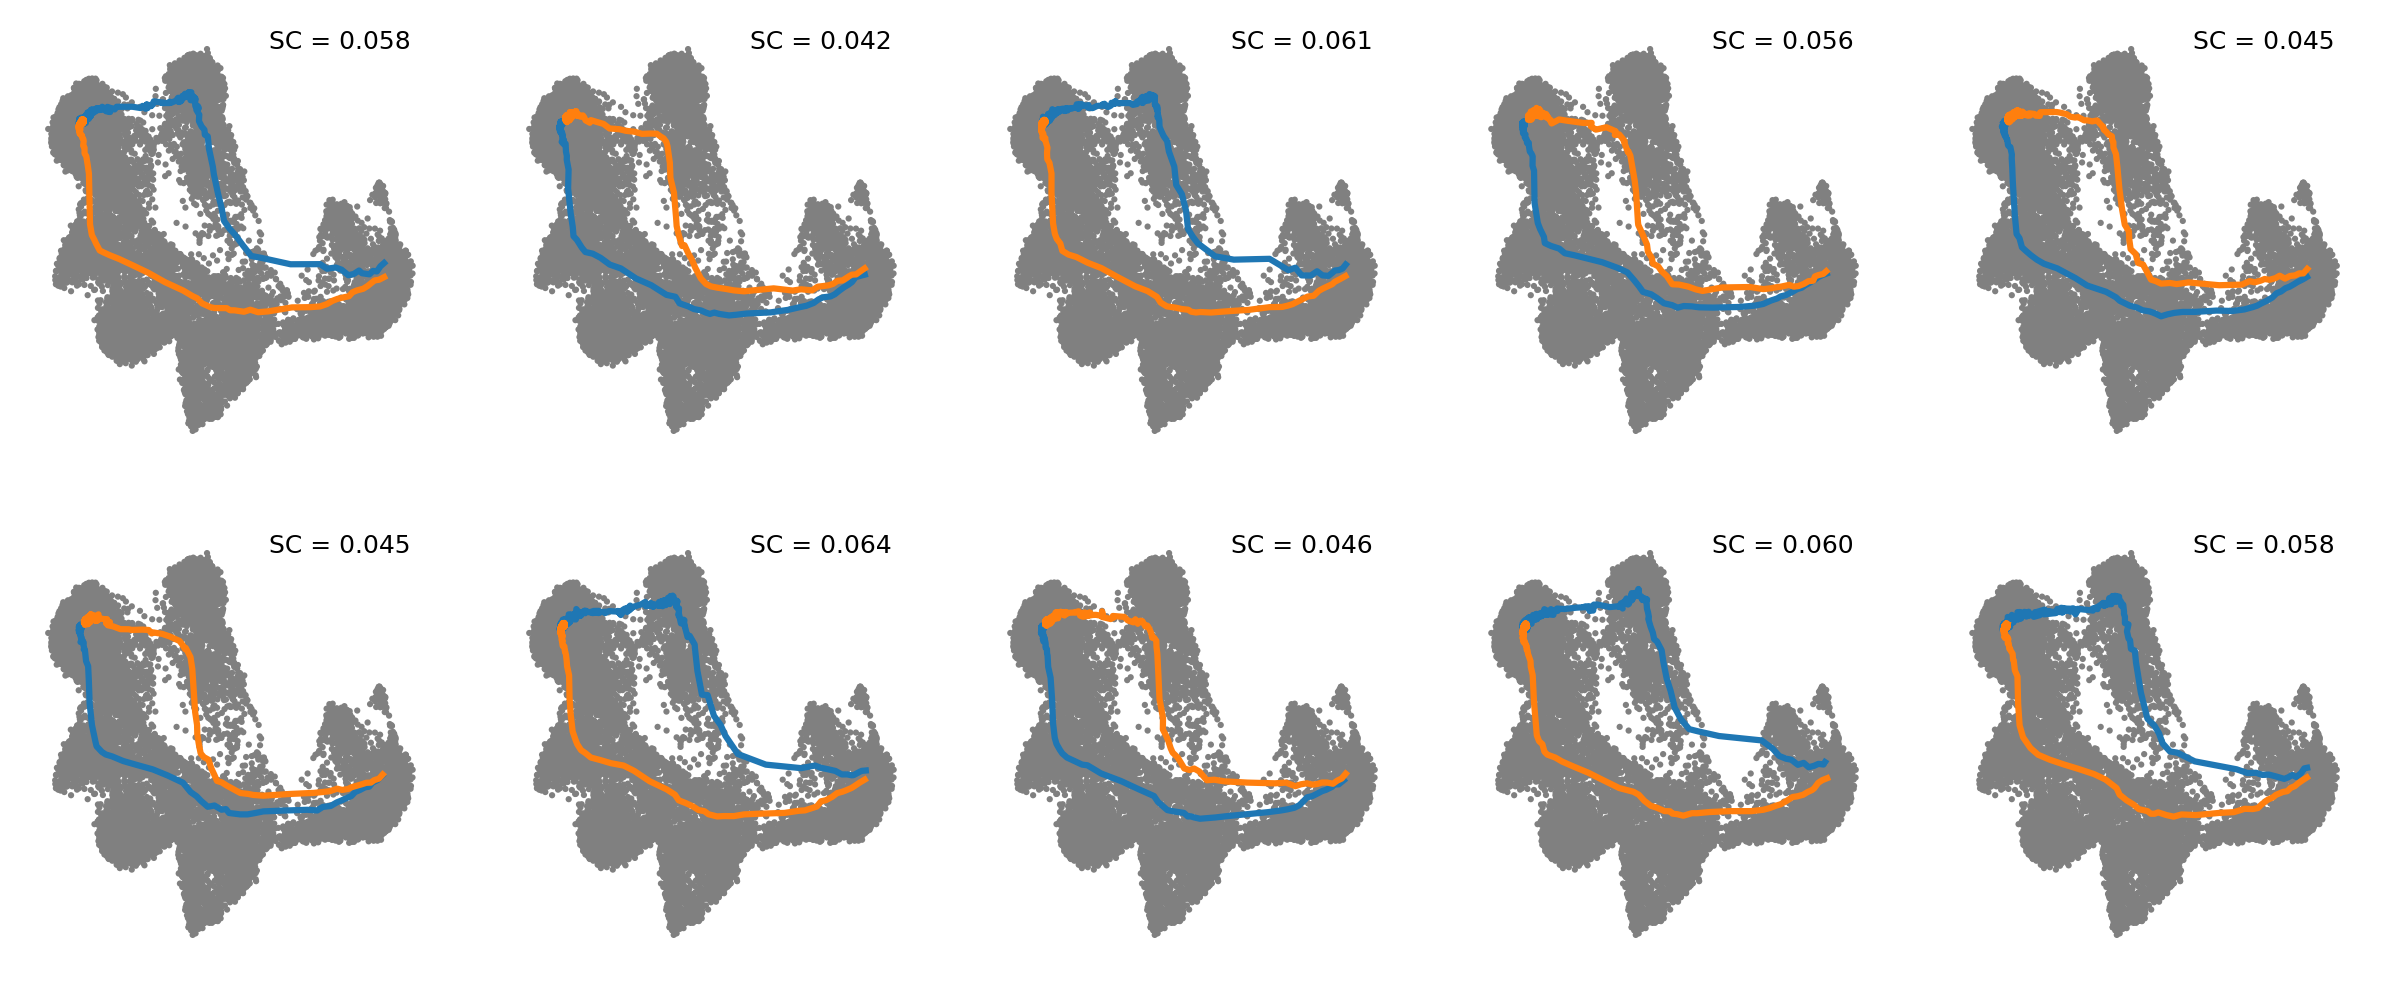

In [11]:
# Plot for 2 lineages, 500 steps
n_lineages = 2
num_steps = 500
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for run_number, markov_chains in markov_chains_dict.items():
    adata_.uns["markov_chain_sampling"] = {}
    adata_.uns["markov_chain_sampling"]["state_indices"] = markov_chains[:, :num_steps]
    adata_.uns["cytopath"] = {}
    if (
        run_number not in clusterings_dict[num_steps]
    ):  # remove after rerunning clustering
        continue
    adata_.uns["cytopath"]["lineage_inference_clusters"] = clusterings_dict[num_steps][
        run_number
    ][n_lineages]
    c2p.plot_cytopath_lineages(adata_, basis="umap", ax=axs.flat[run_number])
    axs.flat[run_number].text(
        0.95,
        1.0,
        f"SC = {silhouette_scores_dict[num_steps][run_number][str(n_lineages)]:.3f}",
        ha="right",
        va="top",
        transform=axs.flat[run_number].transAxes,
        size=6,
    )

In [ ]:
# Compute the trajectory coordinates in PC and UMAP space
trajectories_pca = {}
trajectories_umap = {}

# Iterate over different chain lengths
for num_steps, clusterings_sub_dict in clusterings_dict.items():
    trajectories_pca[num_steps] = {}
    trajectories_umap[num_steps] = {}

    # Iterate over different runs
    for run_number, markov_chains in markov_chains_dict.items():
        trajectories_pca[num_steps][run_number] = {}
        trajectories_umap[num_steps][run_number] = {}

        # Iterate over different numbers of lineages
        if (
            run_number not in clusterings_sub_dict.keys()
        ):  # remove after rerunning clustering
            continue
        for n_lineages, clustering in clusterings_sub_dict[run_number].items():
            trajectories_pca[num_steps][run_number][n_lineages] = np.zeros(
                (n_lineages, num_steps, adata.obsm["X_pca"].shape[1]), dtype="double"
            )
            trajectories_umap[num_steps][run_number][n_lineages] = np.zeros(
                (n_lineages, num_steps, adata.obsm["X_umap"].shape[1])
            )

            # Iterate over lineages and compute their coordinates
            for i in range(n_lineages):
                indices = np.where(clustering == i + 1)[0]
                chains = markov_chains[indices, :num_steps]
                trajectories_pca[num_steps][run_number][n_lineages][i, :, :] = (
                    np.median(adata.obsm["X_pca"][chains], axis=0)
                )
                trajectories_umap[num_steps][run_number][n_lineages][i, :, :] = (
                    np.median(adata.obsm["X_umap"][chains], axis=0)
                )

In [ ]:
# Compute lineage mapping between runs, using lineages from first run as reference
# Output for each run and n_lineages is the order of lineages matching the reference lineages
num_steps_list = sorted(clusterings_dict.keys())
lineage_orders = {
    num_steps: {
        n_lineages: [list(range(n_lineages))]
        for n_lineages in range(
            silhouette_scores_df.num_lineages.astype(int).min(),
            silhouette_scores_df.num_lineages.astype(int).max() + 1,
        )
    }
    for num_steps in num_steps_list
}
for num_steps in num_steps_list:
    ref_trajectories = trajectories_pca[num_steps][0]
    for run_number in range(1, len(trajectories_pca[num_steps])):
        if (
            run_number not in trajectories_pca[num_steps].keys()
        ):  # remove after rerunning clustering
            continue
        trajectories = trajectories_pca[num_steps][run_number]
        for n_lineages, trajectory_coords in trajectories.items():
            dist_mat = dtw_ndim.distance_matrix_fast(
                np.vstack([ref_trajectories[n_lineages], trajectory_coords]),
                block=((0, n_lineages), (n_lineages, 2 * n_lineages)),
            )[:n_lineages, n_lineages:]
            mapping = {}
            # Greedily choose the argmin as the mapping
            for i in range(n_lineages):
                idx_ref, idx_other = np.unravel_index(dist_mat.argmin(), dist_mat.shape)
                mapping[idx_ref] = idx_other
                # Remove rows and cols that are already mapped
                dist_mat[idx_ref, :] = np.inf
                dist_mat[:, idx_other] = np.inf
            lineage_orders[num_steps][n_lineages].append(
                [mapping[i] for i in range(n_lineages)]
            )

In [ ]:
# Compute mean and std of inferred UMAP coordinates
lineage_coords_all = {}
lineage_coords_mean = {}
lineage_coords_std = {}
for num_steps in num_steps_list:
    lineage_coords_all[num_steps] = {}
    for n_lineages in range(
        min(list(lineage_orders[num_steps].keys())),
        max(list(lineage_orders[num_steps].keys())) + 1,
    ):
        lineage_coords_all[num_steps][n_lineages] = np.stack(
            [
                trajectories_umap[num_steps][run_number][n_lineages][
                    lineage_orders[num_steps][n_lineages][run_number]
                ]
                for run_number in range(len(trajectories_umap[num_steps]))
            ]
        )
    lineage_coords_mean[num_steps] = {
        n_lineages: np.mean(coords, axis=0)
        for n_lineages, coords in lineage_coords_all[num_steps].items()
    }
    lineage_coords_std[num_steps] = {
        n_lineages: np.std(coords, axis=0)
        for n_lineages, coords in lineage_coords_all[num_steps].items()
    }

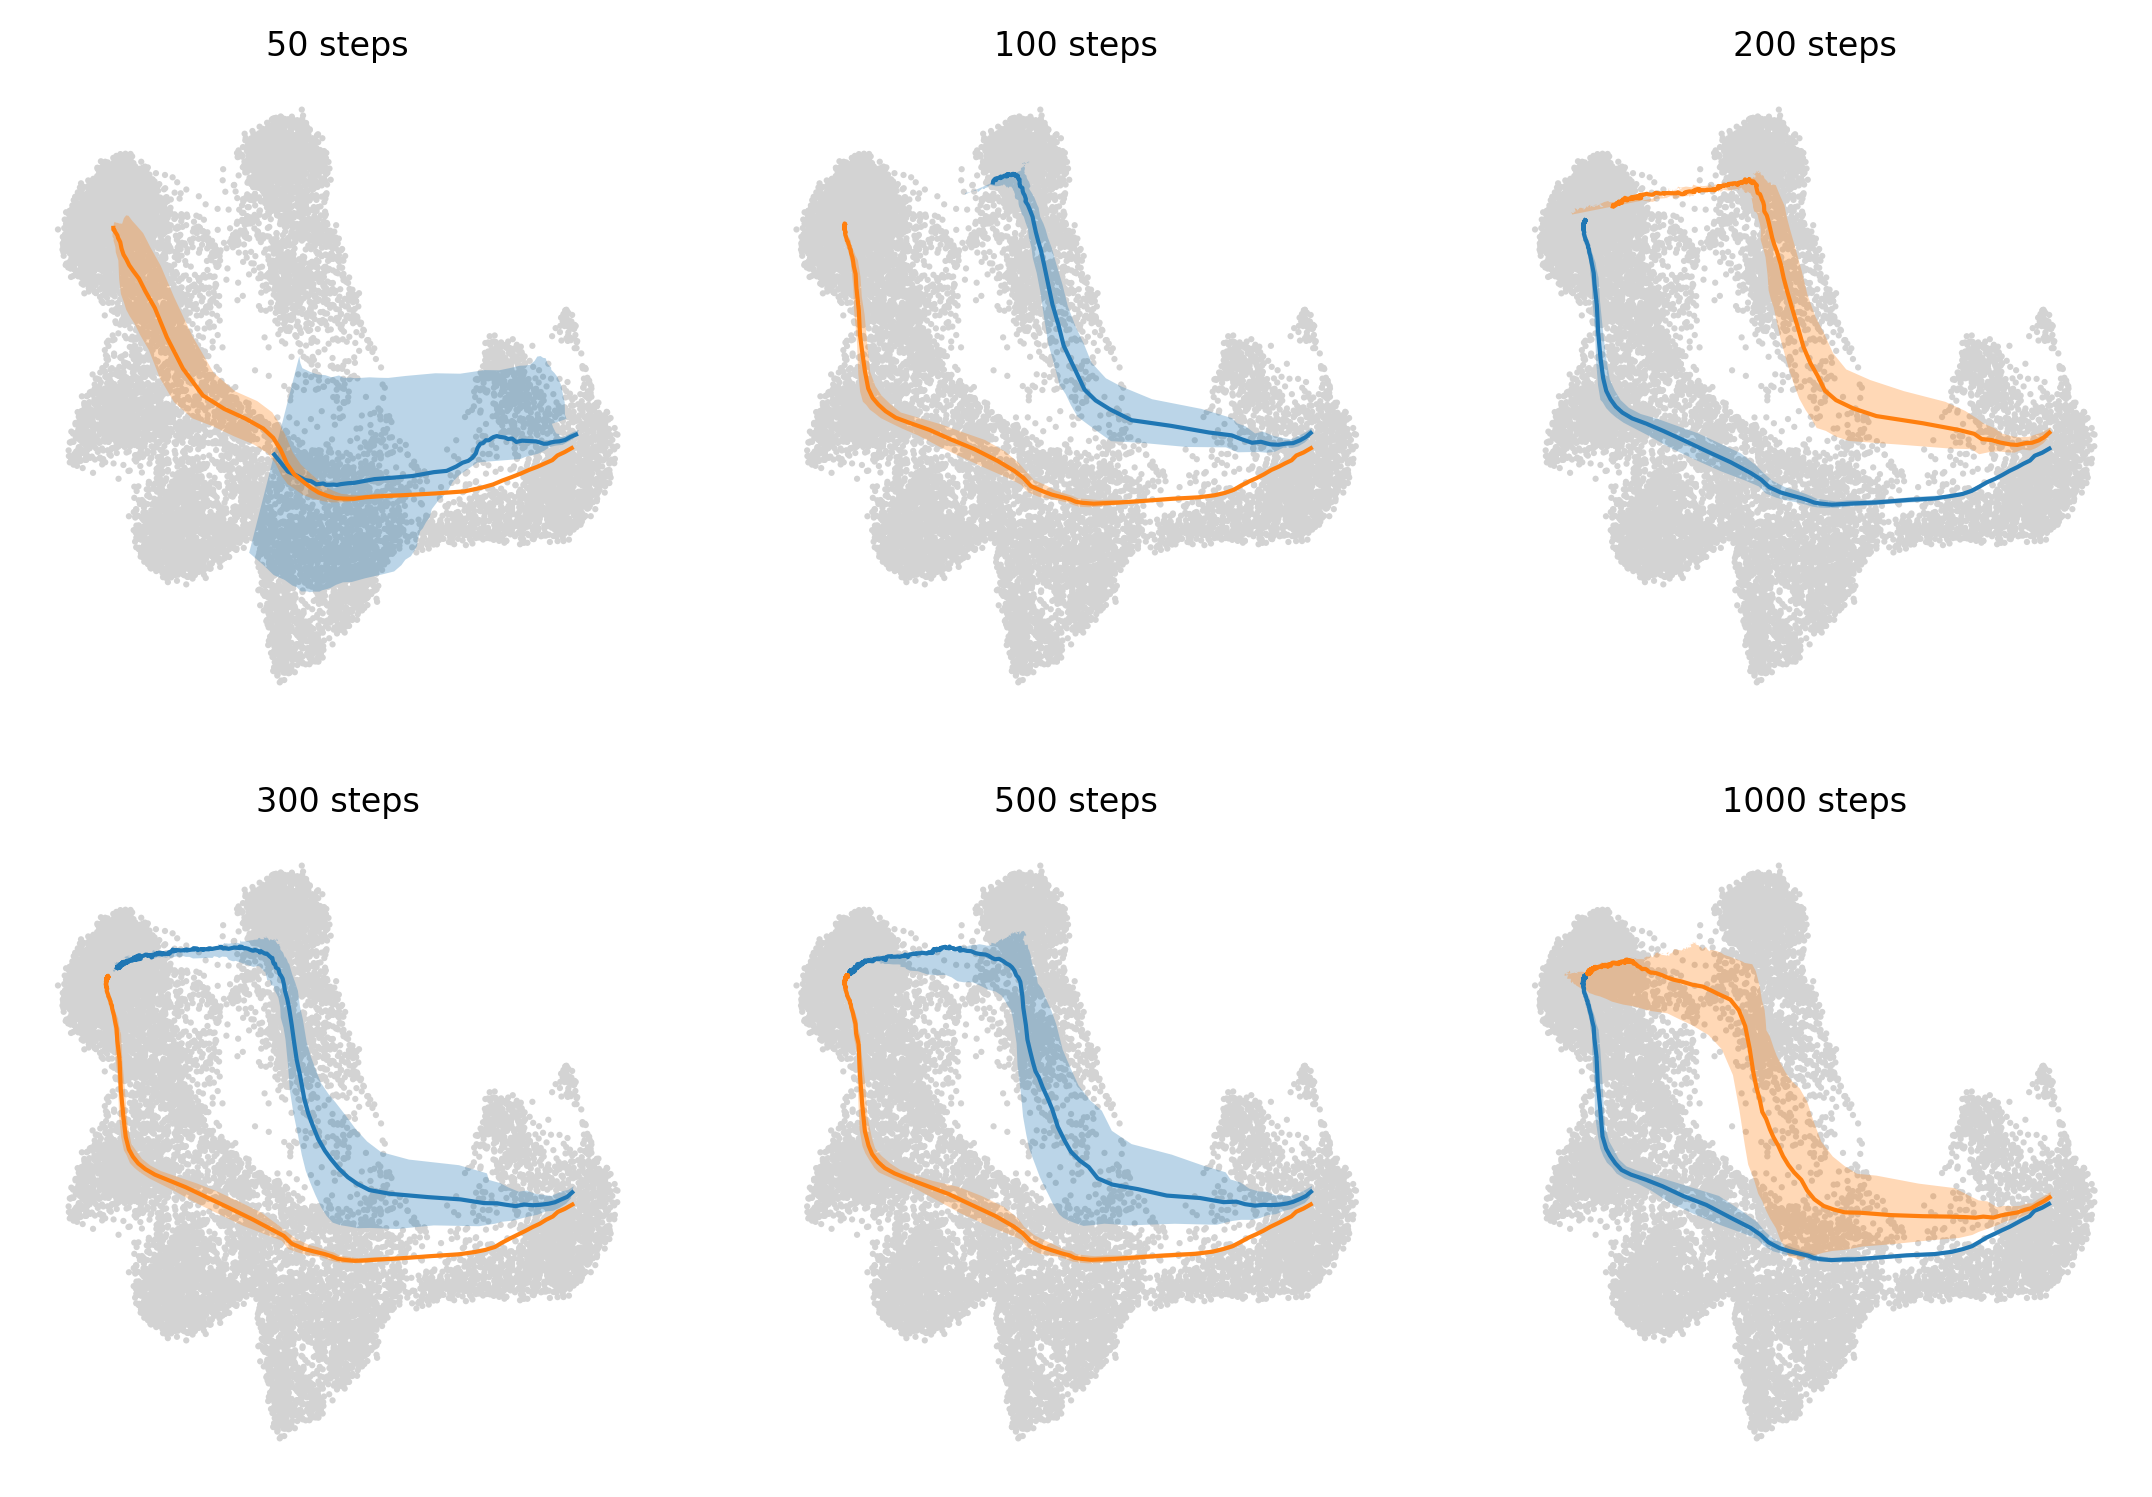

In [15]:
# Plot trajectories and their uncertainty
fig, axs = plt.subplots(2, 3, figsize=(9, 6))

n_lineages = 2

for i, num_steps in enumerate(num_steps_list):
    ax = axs.flat[i]
    sc.pl.umap(adata, ax=ax, show=False, frameon=False)
    for i, lineage in enumerate(lineage_coords_mean[num_steps][n_lineages]):
        color = f"C{i}"
        ax.plot(lineage[:, 0], lineage[:, 1], lw=1, c=color)
        region_lower = lineage - lineage_coords_std[num_steps][n_lineages][i]
        region_upper = lineage + lineage_coords_std[num_steps][n_lineages][i]
        xf = np.concatenate((region_lower[:, 0], region_upper[:, 0][::-1]))
        yf = np.concatenate((region_lower[:, 1], region_upper[:, 1][::-1]))
        ax.fill(xf, yf, c=color, alpha=0.3, lw=0)
    ax.set_title(f"{num_steps} steps", fontsize=8)

In [18]:
for num_steps in num_steps_list:
    for n_lineages in range(
        min(list(lineage_coords_all[num_steps].keys())),
        max(list(lineage_coords_all[num_steps].keys())) + 1,
    ):
        np.save(
            f"{LINEAGE_PATH}/{num_steps}_steps/lineage_coords_all_{n_lineages}_lineages.npy",
            lineage_coords_all[num_steps][num_lineages],
        )
        np.save(
            f"{LINEAGE_PATH}/{num_steps}_steps/lineage_coords_mean_{n_lineages}_lineages.npy",
            lineage_coords_mean[num_steps][n_lineages],
        )
        np.save(
            f"{LINEAGE_PATH}/{num_steps}_steps/lineage_coords_std_{n_lineages}_lineages.npy",
            lineage_coords_std[num_steps][n_lineages],
        )